In [44]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


# Data Loading & Preprocessing

In [46]:
filepath = "/content/drive/MyDrive/power prediction in combined cycle power plant/ccpp_data.csv"

power_df = pd.read_csv(filepath)
power_df.head()


,AT,V,AP,RH,PE
0,29.07,72.51,1009.24,58.38,449.371855
1,32.38,67.17,1006.97,60.04,450.861043
2,19.29,67.71,1007.94,63.71,460.894029
3,16.45,41.48,1016.64,45.21,467.577314
4,21.43,46.97,1013.94,61.25,469.805723


In [47]:
power_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [48]:
print(power_df.isnull().sum())

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


In [49]:
print(power_df.duplicated().sum())

0


# Statistical Analysis

## Outliers

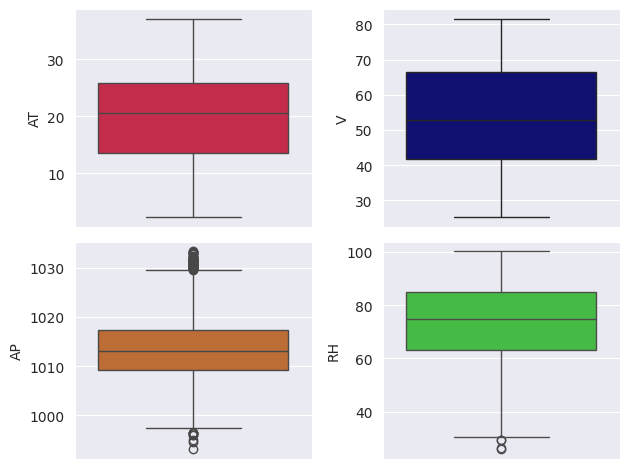

In [50]:
# visualize the boxplot
plt.subplot(2, 2, 1)
sns.boxplot(power_df['AT'], color = "crimson")

plt.subplot(2, 2, 2)
sns.boxplot(power_df['V'], color = "navy")

plt.subplot(2, 2, 3)
sns.boxplot(power_df['AP'], color = "chocolate")

plt.subplot(2, 2, 4)
sns.boxplot(power_df['RH'], color = "limegreen")

plt.tight_layout()
plt.show()

In [51]:
feature_cols = ['AT', 'V', 'AP', 'RH']

q1 = power_df[feature_cols].quantile(0.25)
q3 = power_df[feature_cols].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = ~((power_df[feature_cols] < lower_bound) | (power_df[feature_cols] > upper_bound)).any(axis = 1)

power_df = power_df[outlier_mask].reset_index(drop = True)

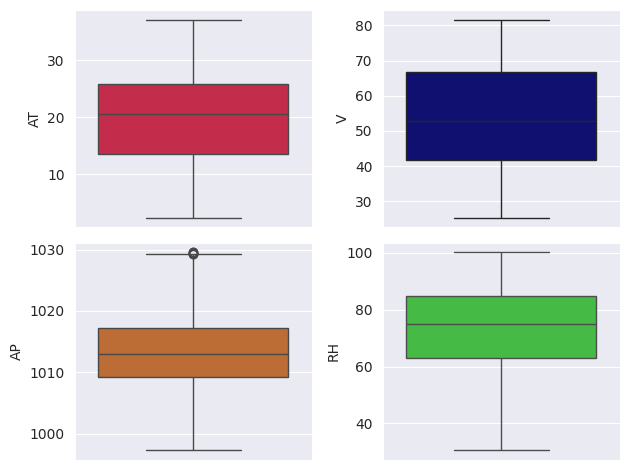

In [52]:
# visualize the boxplot
plt.subplot(2, 2, 1)
sns.boxplot(power_df['AT'], color = "crimson")

plt.subplot(2, 2, 2)
sns.boxplot(power_df['V'], color = "navy")

plt.subplot(2, 2, 3)
sns.boxplot(power_df['AP'], color = "chocolate")

plt.subplot(2, 2, 4)
sns.boxplot(power_df['RH'], color = "limegreen")

plt.tight_layout()
plt.show()

## Pearson Correlation & P-values

In [53]:
for feature in feature_cols:
    coef, pval = stats.pearsonr(power_df[feature], power_df['PE'])
    print("feature: {} \t correlation: {:.4f} \t p-value: {:.4f}".format(feature, coef, pval))

feature: AT 	 correlation: -0.9459 	 p-value: 0.0000
feature: V 	 correlation: -0.8667 	 p-value: 0.0000
feature: AP 	 correlation: 0.5229 	 p-value: 0.0000
feature: RH 	 correlation: 0.3868 	 p-value: 0.0000


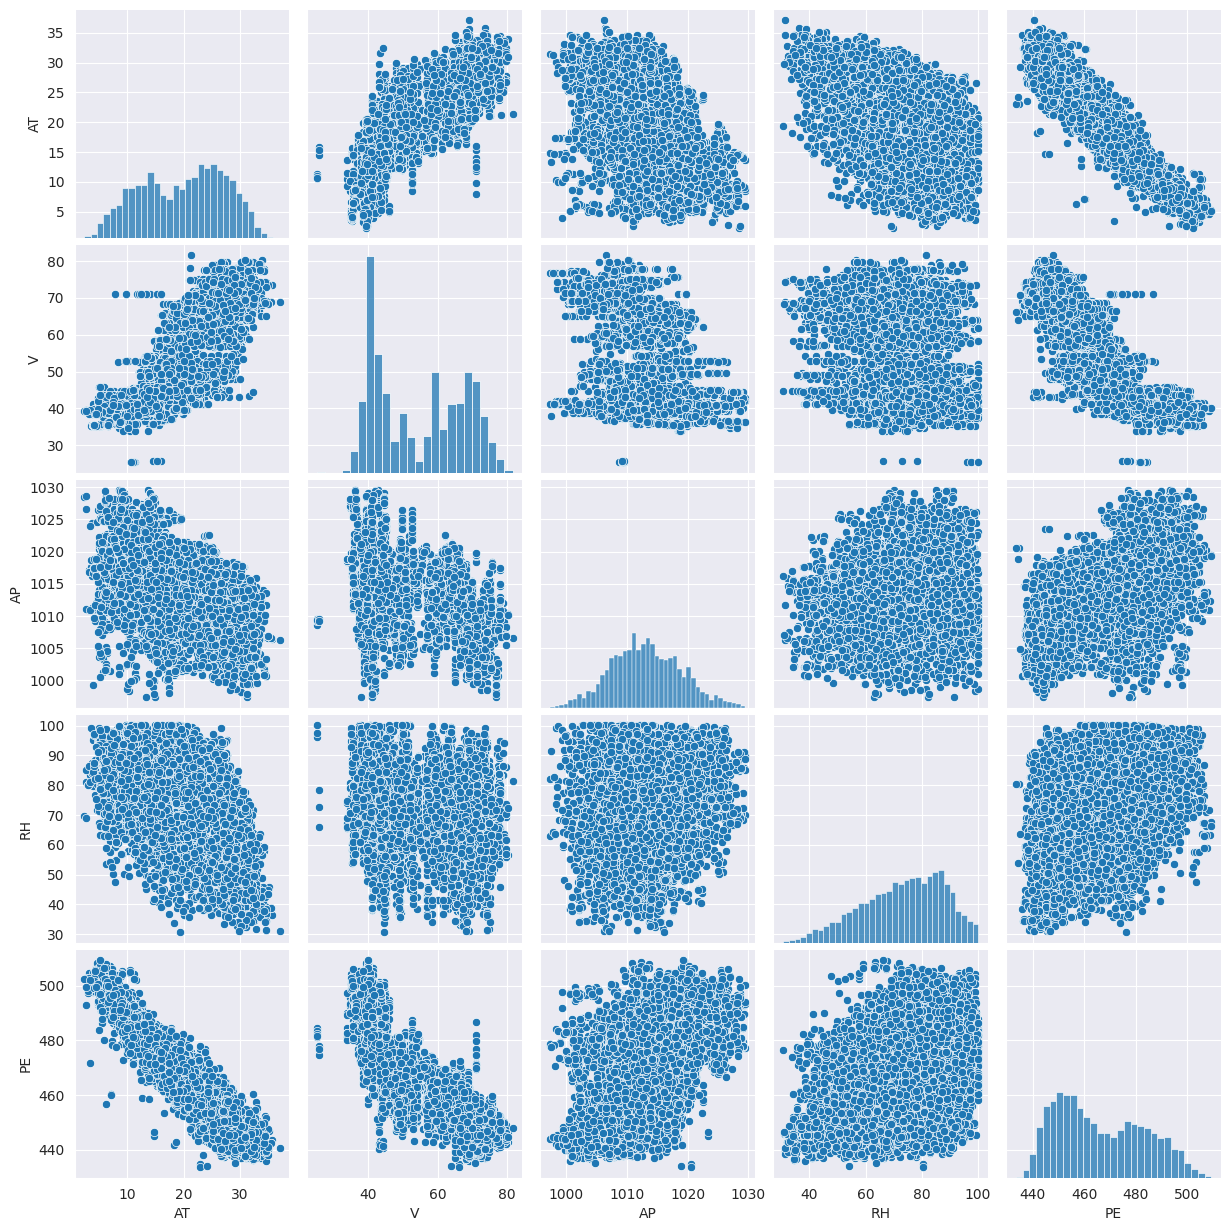

In [54]:
sns.pairplot(power_df)
plt.show()

## Data Splitting & Scaling

In [55]:
X = power_df.drop(columns = ['PE'])
y = power_df['PE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [56]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training (Machine Learning) & Evaluation

### Evaluation Model Function

In [57]:
result = {}

In [58]:
def evaluate_model(model_name, best_model, X_test_data):
  preds = best_model.best_estimator_.predict(X_test_data)
  r2 = r2_score(y_test, preds)
  mae = mean_absolute_error(y_test, preds)
  mse = mean_squared_error(y_test, preds)
  rmse = np.sqrt(mse)

  result[model_name] = {'R2': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'best estimators': best_model.best_params_}
  print("Model: {}".format(model_name))
  print("R2 Score: {:.4f}".format(r2))
  print("Mean Absolute Error: {:.4f}".format(mae))
  print("Mean Squared Error: {:.4f}".format(mse))
  print("Root Mean Squared Error: {:.4f}".format(rmse))
  print()

In [59]:
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

### Linear Regression

In [60]:
lr_param_grid = {'fit_intercept': [True, False]}
grid_lr = GridSearchCV(LinearRegression(),
                       lr_param_grid, cv = cv,
                       scoring = 'neg_mean_squared_error',
                       verbose = 3,
                       return_train_score = True)
grid_lr.fit(X_train, y_train)
evaluate_model('Linear Regression', grid_lr, X_test)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV 1/5] END fit_intercept=True;, score=(train=-21.714, test=-20.944) total time=   0.0s
[CV 2/5] END fit_intercept=True;, score=(train=-21.269, test=-22.713) total time=   0.0s
[CV 3/5] END fit_intercept=True;, score=(train=-21.695, test=-21.000) total time=   0.0s
[CV 4/5] END fit_intercept=True;, score=(train=-21.208, test=-22.965) total time=   0.0s
[CV 5/5] END fit_intercept=True;, score=(train=-21.867, test=-20.312) total time=   0.0s
[CV 1/5] END fit_intercept=False;, score=(train=-217611.526, test=-217891.852) total time=   0.0s
[CV 2/5] END fit_intercept=False;, score=(train=-217615.765, test=-217803.968) total time=   0.0s
[CV 3/5] END fit_intercept=False;, score=(train=-217640.433, test=-217666.360) total time=   0.0s
[CV 4/5] END fit_intercept=False;, score=(train=-217621.056, test=-217753.274) total time=   0.0s
[CV 5/5] END fit_intercept=False;, score=(train=-217607.843, test=-217804.708) total time=   0.0s
Model

In [61]:
ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0],
                    'solver': ['auto', 'svd', 'cholesky']}
grid_ridge = GridSearchCV(Ridge(random_state = 42),
                       ridge_param_grid, cv = cv,
                       scoring = 'neg_mean_squared_error',
                       verbose = 3,
                       return_train_score = True)
grid_ridge.fit(X_train, y_train)
evaluate_model('Ridge Regression', grid_ridge, X_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END alpha=0.01, solver=auto;, score=(train=-21.714, test=-20.944) total time=   0.0s
[CV 2/5] END alpha=0.01, solver=auto;, score=(train=-21.269, test=-22.713) total time=   0.0s
[CV 3/5] END alpha=0.01, solver=auto;, score=(train=-21.695, test=-21.000) total time=   0.0s
[CV 4/5] END alpha=0.01, solver=auto;, score=(train=-21.208, test=-22.965) total time=   0.0s
[CV 5/5] END alpha=0.01, solver=auto;, score=(train=-21.867, test=-20.312) total time=   0.0s
[CV 1/5] END alpha=0.01, solver=svd;, score=(train=-21.714, test=-20.944) total time=   0.0s
[CV 2/5] END alpha=0.01, solver=svd;, score=(train=-21.269, test=-22.713) total time=   0.0s
[CV 3/5] END alpha=0.01, solver=svd;, score=(train=-21.695, test=-21.000) total time=   0.0s
[CV 4/5] END alpha=0.01, solver=svd;, score=(train=-21.208, test=-22.965) total time=   0.0s
[CV 5/5] END alpha=0.01, solver=svd;, score=(train=-21.867, test=-20.312) total time=   0.0s
[CV 

In [62]:
lasso_param_grid = {'alpha': [0.01, 1.0, 10.0],
                    'selection': ['cyclic', 'random']}
grid_lasso = GridSearchCV(Lasso(random_state = 42, max_iter = 10000),
                        lasso_param_grid, cv = cv,
                        scoring = 'neg_mean_squared_error',
                          verbose = 3,
                          return_train_score = True)
grid_lasso.fit(X_train, y_train)
evaluate_model('Lasso Regression', grid_lasso, X_test)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END alpha=0.01, selection=cyclic;, score=(train=-21.715, test=-20.952) total time=   0.0s
[CV 2/5] END alpha=0.01, selection=cyclic;, score=(train=-21.269, test=-22.715) total time=   0.0s
[CV 3/5] END alpha=0.01, selection=cyclic;, score=(train=-21.695, test=-20.996) total time=   0.0s
[CV 4/5] END alpha=0.01, selection=cyclic;, score=(train=-21.209, test=-22.957) total time=   0.0s
[CV 5/5] END alpha=0.01, selection=cyclic;, score=(train=-21.868, test=-20.316) total time=   0.0s
[CV 1/5] END alpha=0.01, selection=random;, score=(train=-21.715, test=-20.952) total time=   0.0s
[CV 2/5] END alpha=0.01, selection=random;, score=(train=-21.269, test=-22.715) total time=   0.0s
[CV 3/5] END alpha=0.01, selection=random;, score=(train=-21.695, test=-20.996) total time=   0.0s
[CV 4/5] END alpha=0.01, selection=random;, score=(train=-21.209, test=-22.957) total time=   0.0s
[CV 5/5] END alpha=0.01, selection=random;, score

In [63]:
elastic_param_grid = {'alpha': [0.01, 1.0, 10.0],
                    'l1_ratio': [0.2, 0.5, 0.8]}
grid_elastic = GridSearchCV(ElasticNet(random_state = 42, max_iter = 10000),
                            elastic_param_grid, cv = cv,
                            scoring = 'neg_mean_squared_error',
                            verbose = 3,
                            return_train_score = True)
grid_elastic.fit(X_train, y_train)
evaluate_model('Elastic Net Regression', grid_elastic, X_test)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END alpha=0.01, l1_ratio=0.2;, score=(train=-21.774, test=-21.101) total time=   0.0s
[CV 2/5] END alpha=0.01, l1_ratio=0.2;, score=(train=-21.330, test=-22.772) total time=   0.0s
[CV 3/5] END alpha=0.01, l1_ratio=0.2;, score=(train=-21.756, test=-20.992) total time=   0.0s
[CV 4/5] END alpha=0.01, l1_ratio=0.2;, score=(train=-21.270, test=-22.969) total time=   0.0s
[CV 5/5] END alpha=0.01, l1_ratio=0.2;, score=(train=-21.928, test=-20.404) total time=   0.0s
[CV 1/5] END alpha=0.01, l1_ratio=0.5;, score=(train=-21.740, test=-21.036) total time=   0.0s
[CV 2/5] END alpha=0.01, l1_ratio=0.5;, score=(train=-21.296, test=-22.738) total time=   0.0s
[CV 3/5] END alpha=0.01, l1_ratio=0.5;, score=(train=-21.721, test=-20.981) total time=   0.0s
[CV 4/5] END alpha=0.01, l1_ratio=0.5;, score=(train=-21.235, test=-22.952) total time=   0.0s
[CV 5/5] END alpha=0.01, l1_ratio=0.5;, score=(train=-21.894, test=-20.359) total tim

In [64]:
dt_param_grid = {'max_depth': [5, 10, None],
                 'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeRegressor(random_state = 42),
                            dt_param_grid, cv = cv,
                            scoring = 'neg_mean_squared_error',
                            verbose = 3,
                            return_train_score = True)
grid_dt.fit(X_train, y_train)
evaluate_model('Decision Tree Regressor', grid_dt, X_test)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END max_depth=5, min_samples_split=2;, score=(train=-18.871, test=-19.111) total time=   0.0s
[CV 2/5] END max_depth=5, min_samples_split=2;, score=(train=-18.098, test=-21.479) total time=   0.0s
[CV 3/5] END max_depth=5, min_samples_split=2;, score=(train=-18.766, test=-19.830) total time=   0.0s
[CV 4/5] END max_depth=5, min_samples_split=2;, score=(train=-18.283, test=-20.926) total time=   0.0s
[CV 5/5] END max_depth=5, min_samples_split=2;, score=(train=-18.737, test=-19.943) total time=   0.0s
[CV 1/5] END max_depth=5, min_samples_split=5;, score=(train=-18.871, test=-19.111) total time=   0.0s
[CV 2/5] END max_depth=5, min_samples_split=5;, score=(train=-18.098, test=-21.479) total time=   0.0s
[CV 3/5] END max_depth=5, min_samples_split=5;, score=(train=-18.766, test=-19.830) total time=   0.0s
[CV 4/5] END max_depth=5, min_samples_split=5;, score=(train=-18.283, test=-20.926) total time=   0.0s
[CV 5/5] END 

In [65]:
rf_param_grid = {'n_estimators': [50, 100, 150],
                 'max_depth': [3, 4, 5],
                 'min_samples_split': [2, 5, 10]}
grid_rf = GridSearchCV(RandomForestRegressor(random_state = 42),
                            rf_param_grid, cv = cv,
                            scoring = 'neg_mean_squared_error',
                            verbose = 3,
                            return_train_score = True)
grid_rf.fit(X_train, y_train)
evaluate_model('Random Forest Regressor', grid_rf, X_test)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV 1/5] END max_depth=3, min_samples_split=2, n_estimators=50;, score=(train=-23.311, test=-23.362) total time=   0.4s
[CV 2/5] END max_depth=3, min_samples_split=2, n_estimators=50;, score=(train=-24.253, test=-25.843) total time=   0.4s
[CV 3/5] END max_depth=3, min_samples_split=2, n_estimators=50;, score=(train=-23.920, test=-23.886) total time=   0.4s
[CV 4/5] END max_depth=3, min_samples_split=2, n_estimators=50;, score=(train=-23.062, test=-24.708) total time=   0.4s
[CV 5/5] END max_depth=3, min_samples_split=2, n_estimators=50;, score=(train=-24.004, test=-24.075) total time=   0.4s
[CV 1/5] END max_depth=3, min_samples_split=2, n_estimators=100;, score=(train=-23.295, test=-23.358) total time=   0.8s
[CV 2/5] END max_depth=3, min_samples_split=2, n_estimators=100;, score=(train=-24.071, test=-25.661) total time=   0.8s
[CV 3/5] END max_depth=3, min_samples_split=2, n_estimators=100;, score=(train=-23.789, test=-23

## Model Comparison

In [66]:
results_df = pd.DataFrame(result).T
results_df.head()

,R2,MAE,MSE,RMSE,best estimators
Linear Regression,0.921857,3.787928,22.469631,4.740214,{'fit_intercept': True}
Ridge Regression,0.921858,3.787917,22.469467,4.740197,"{'alpha': 0.1, 'solver': 'auto'}"
Lasso Regression,0.92187,3.787666,22.465997,4.739831,"{'alpha': 0.01, 'selection': 'cyclic'}"
Elastic Net Regression,0.921935,3.78636,22.447169,4.737844,"{'alpha': 0.01, 'l1_ratio': 0.8}"
Decision Tree Regressor,0.94895,2.659732,14.679149,3.831338,"{'max_depth': None, 'min_samples_split': 10}"


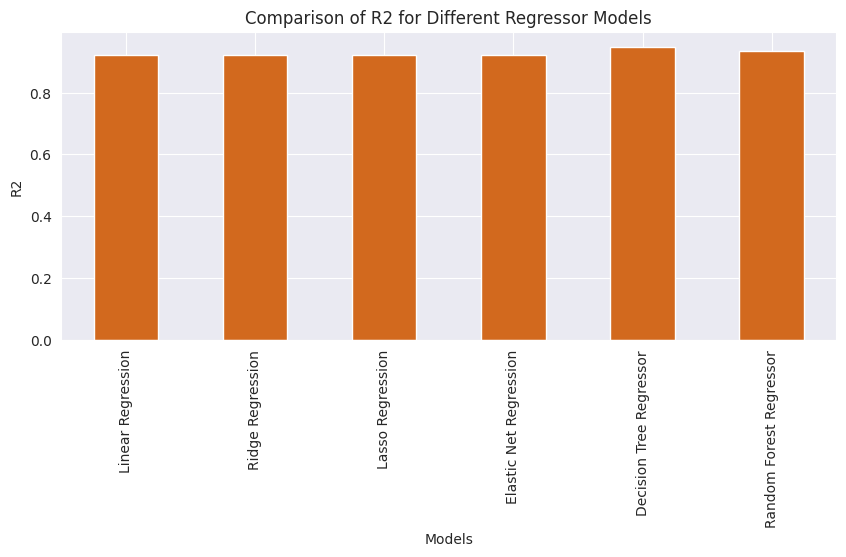

In [67]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 4))
results_df['R2'].plot(kind = "bar", color = "chocolate")
plt.title("Comparison of R2 for Different Regressor Models")
plt.xlabel("Models")
plt.ylabel("R2")
plt.show()

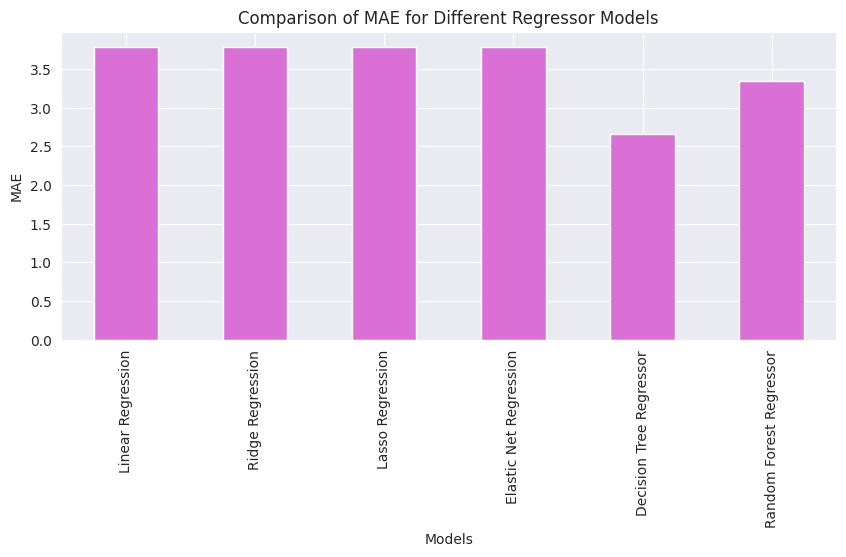

In [68]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 4))
results_df['MAE'].plot(kind = "bar", color = "orchid")
plt.title("Comparison of MAE for Different Regressor Models")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.show()

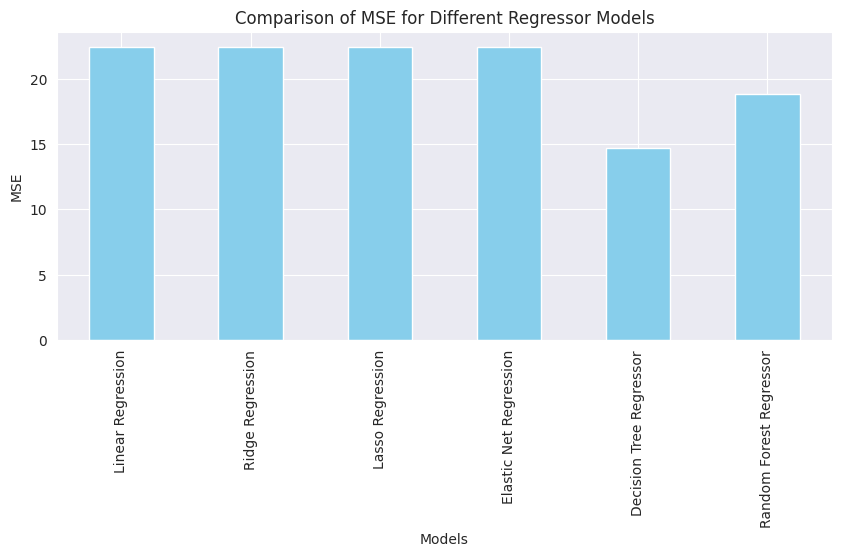

In [69]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 4))
results_df['MSE'].plot(kind = "bar", color = "skyblue")
plt.title("Comparison of MSE for Different Regressor Models")
plt.xlabel("Models")
plt.ylabel("MSE")
plt.show()

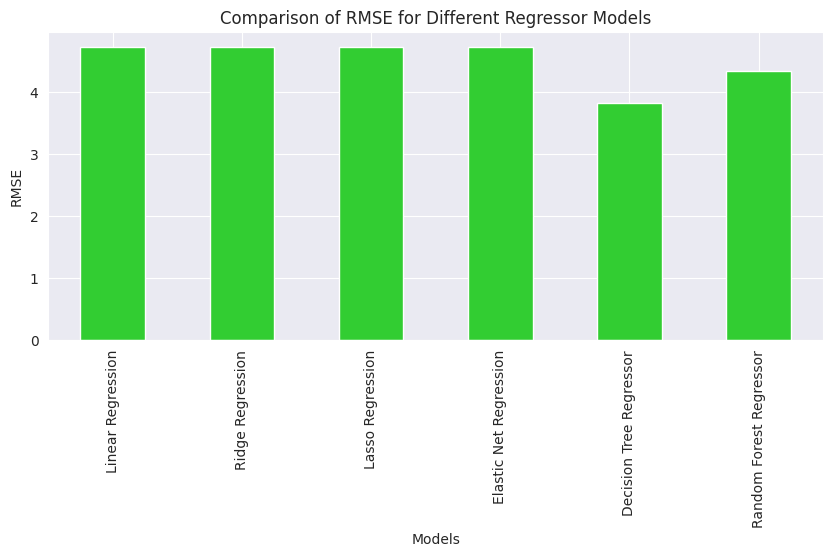

In [70]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 4))
results_df['RMSE'].plot(kind = "bar", color = "limegreen")
plt.title("Comparison of RMSE for Different Regressor Models")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.show()